因果关系

In [4]:
import torch
from torch import nn
from d2l import torch as d2l

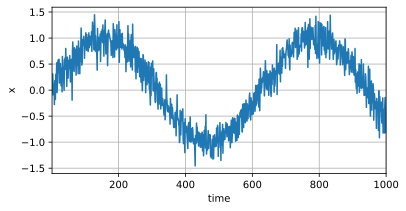

In [5]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [ ]:
tau = 4
features = torch.zeros(T - tau, tau)
for i in range(tau):
    features[:, i] = x[i : T - tau + i]
labels = x[tau:].reshape((-1, 1)) # -1表示自动计算这一个维度的数量
batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

In [7]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                         nn.ReLU(),
                         nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

In [8]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch:{epoch + 1}, loss : {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch:1, loss : 0.069736
epoch:2, loss : 0.059664
epoch:3, loss : 0.055131
epoch:4, loss : 0.052623
epoch:5, loss : 0.051058


预测

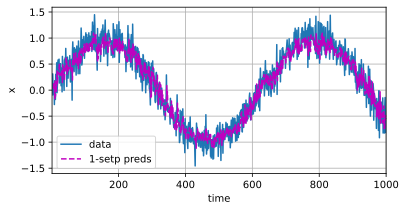

In [ ]:
onestep_preds = net(features) # 把features放到训练好的net中
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()],
         'time', 'x', legend=['data','1-setp preds'],
         xlim=[1, 1000], figsize=(6,3))

In [16]:
onestep_preds.size()

torch.Size([996, 1])

In [10]:
max_steps = 64

In [12]:
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
for i in range(tau):
    features[:, i] = x[i : i + T - tau - max_steps + 1]

for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

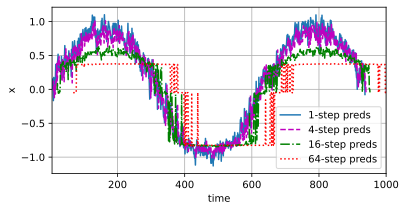

In [13]:
steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1:T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 
         'time', 'x',
         legend = [f'{i}-step preds' for i in steps],
         xlim = [5, 1000], figsize = (6, 3))